In [81]:
# # 연습문제 
# 데이터불러오기 
# 데이터를 불러왔으니까, 
# 그게 무슨 데이터인지 확인을 해야 겠지.

# 결측치있는지, 
# 중복 데이터가 있는지, 중복이 있다면 제거를 해야 하는데
# 비중에 따라 어떤 항목이 너무 많으면? 그냥 그 항목을 지워버리는 방법도 있음 
# + 로지스틱 이항(0/1)만 허용하므로, 확정되지 않은 애매한 범주행을 제거 
# 설명력이 없는 컬럼은 삭제


# 케이스별로 판단해야 하는 것들
# 범주형 라벨링/더미변수
# 이상치대체
# 로그변환
# 0값 결측치 변환
# 다중공선성 점검 VIF


# 데이터 타입이 무슨 타입인지, 
# 연속형인지 범주형인지, 
# 그 설정이 제대로 되어있는지 확인. 
# 범주형으로 바꿔야 한다면, 범주형으로 바꾸기. 
# 연속형 변수의 기초 통계 확인하기 

# 합격 여부를 설명하는 요소.

# 로지스틱 회귀 

# 예측 
# new_data에는 최종모형에 남아있는 변수만 넣음
# 후진소거로 탈락한 변수는 넣지 않음 



In [82]:
# 자료형 점검 → 결측치 확인 → 중복 제거 → 기초통계
#   ↓
# [케이스A] 종속변수 범주 정리 (보류 제거)
# [케이스B] 식별자 컬럼 제거
#   ↓
# 라벨링 (필수, 범주형 있으면)
# [조건부] 더미/이상치대체/로그변환 (이번엔 해당 없어 스킵)
#   ↓
# VIF 확인 → 다중공선성 변수 제거
#   ↓
# auto_logit (적합 + 후진소거) → 결과표 해석
#   ↓
# predict (최종 모형에 남은 변수만)

올바른 순서 + 왜 이렇게 하는지 (로직)

데이터 불러오기 — 시작점\
자료형 점검(set_type) — 지금 각 컬럼이 판다스한테 숫자로 인식되고 있는지 범주로 인식되고 있는지부터 봐야 함. 왜 여기 먼저냐면, 다음 단계인 결측치/중복 확인 자체가 타입을 전제로 함 — 예를 들어 성별이 숫자(0,1)로 잘못 읽혀 있으면 "범주형 확인"을 해도 엉뚱한 통계(평균 성별 0.5?)가 나옴\

결측치 확인 — 있으면 처리(비중 낮으면 행 제거, 비중 극단적으로 높은 컬럼이면 컬럼째 제거 — 이건 옵션이고 이번엔 해당 없음), 없으면 스킵\

중복 확인 → 제거 — 같은 응시자가 중복 입력됐으면 통계가 왜곡되니까\

기초통계량 확인 (연속형+범주형) — 여기서 종속변수(합격여부)의 범주가 몇 개인지 보게 됨 → 이게 다음 단계로 넘어가는 트리거\

[케이스A] 종속변수 범주 정리 (보류 제거) — 5번에서 3개 범주라는 걸 확인했기 때문에 하는 거지, 무조건 하는 게 아님. 로지스틱은 이항만 허용하니까\

[케이스B] 설명력 없는 식별자 컬럼 삭제 — 접수코드/이름처럼 값 자체가 무작위 식별자라 모델에 넣을 이유가 없는 것들 제거. 이 시점에 하는 이유: VIF 계산 전에 애초에 후보군에서 뺄 건 빼놔야 계산 낭비가 없음\

라벨링(인코딩) — 이제 범주형 값을 숫자로 바꿈. VIF 계산은 숫자만 가능하니까 이게 VIF보다 반드시 먼저\

[조건부] 더미변수/이상치대체/로그변환 — 이번 데이터엔 해당 사항 확인 안 됐으니 스킵 (근거 없이 하면 안 됨)\

VIF 확인 → 다중공선성 변수 제거 — 독립변수끼리 너무 겹치는 정보를 갖고 있으면 계수 추정이 불안정해지니까, 모델 적합 직전에 걸러냄\

auto_logit (적합+후진소거) — 이제서야 모델링. 여기까지 순서가 안 맞으면 이 단계에서 에러 나거나 엉뚱한 결과 나옴\

결과표 해석 — 오즈비/표준화계수로 "무슨 요인이 크게 작용했나" 읽음\

predict — 최종 모형에 남은 변수만 넣어서 새 지원자 확률 계산. 탈락한 변수(성별, 필기점수)는 애초에 모형 계수 자체가 없으니 넣어도 의미 없음\

In [83]:
# 라이브러리 불러오기 
from jussam import load_data
from helpers import * 


In [84]:
# 데이터셋 불러오기 
origin = load_data('pitcher_wins')
origin.head()

📚 야구선수 신맵돌의 실점과 승리 여부를 기록한 데이터


,실점,승리여부
0,4,0
1,1,1
2,3,0
3,3,1
4,2,0


In [85]:
# 로지스틱 회귀 
# 승리 투수가 됐는지 아닌지
# 1 / 0 

# 단순선형회귀와 단순로지스틱을 비교하기 위해, 독립변수 1개, 종속변수 1개인 형태로 전처리를 수행한다.
# 종속변수를 0과 1로 라벨링 한다. 

# 종속변수의 분포 확인
# 집단별 독립변수의 분포 비교 


# 범주형/ 라벨링

# 관측치가 더 많은 값 count

# 로지스틱 

In [86]:
# 데이터셋을 불러오고 난 뒤, 
# 결측치 확인
# 중복값 확인 후 제거 
# 자료형 점검: 연속형/범주형
#     연속형 기초통계량 확인

# 조건부 
#     더미변수/이상치대체/로그변환 
# VIF 다중공선성 변수 제거 


In [87]:
# 필요한 컬럼만 선택 
# 여기서는 실점, 승리여부 
# 지금 로지스틱 회귀를 해야 하니까, 
# 라벨링을 해야 함 

# 데이터셋에서 컬럼을 먼저 선택하고 라벨링 
# 필요한 컬럼만 남긴 다음 라벨링. 깔끔하고 이후 단계에서 추가 필터링이 필요없음
df = origin[['실점', '승리여부']]
df = my_prep.labeling(df, columns=['승리여부'])
df.head()

승리여부 (1종) : 0=0
승리여부 (2종) : 0=0, 1=1


,실점,승리여부
0,4,0
1,1,1
2,3,0
3,3,1
4,2,0


In [88]:
# 종속변수 분포 확인하기 
# 패배가 많은지, 승리가 많은지, 둘의 비율 차이는 어떤지 

origin['승리여부'].value_counts()

승리여부
0    128
1    112
Name: count, dtype: int64

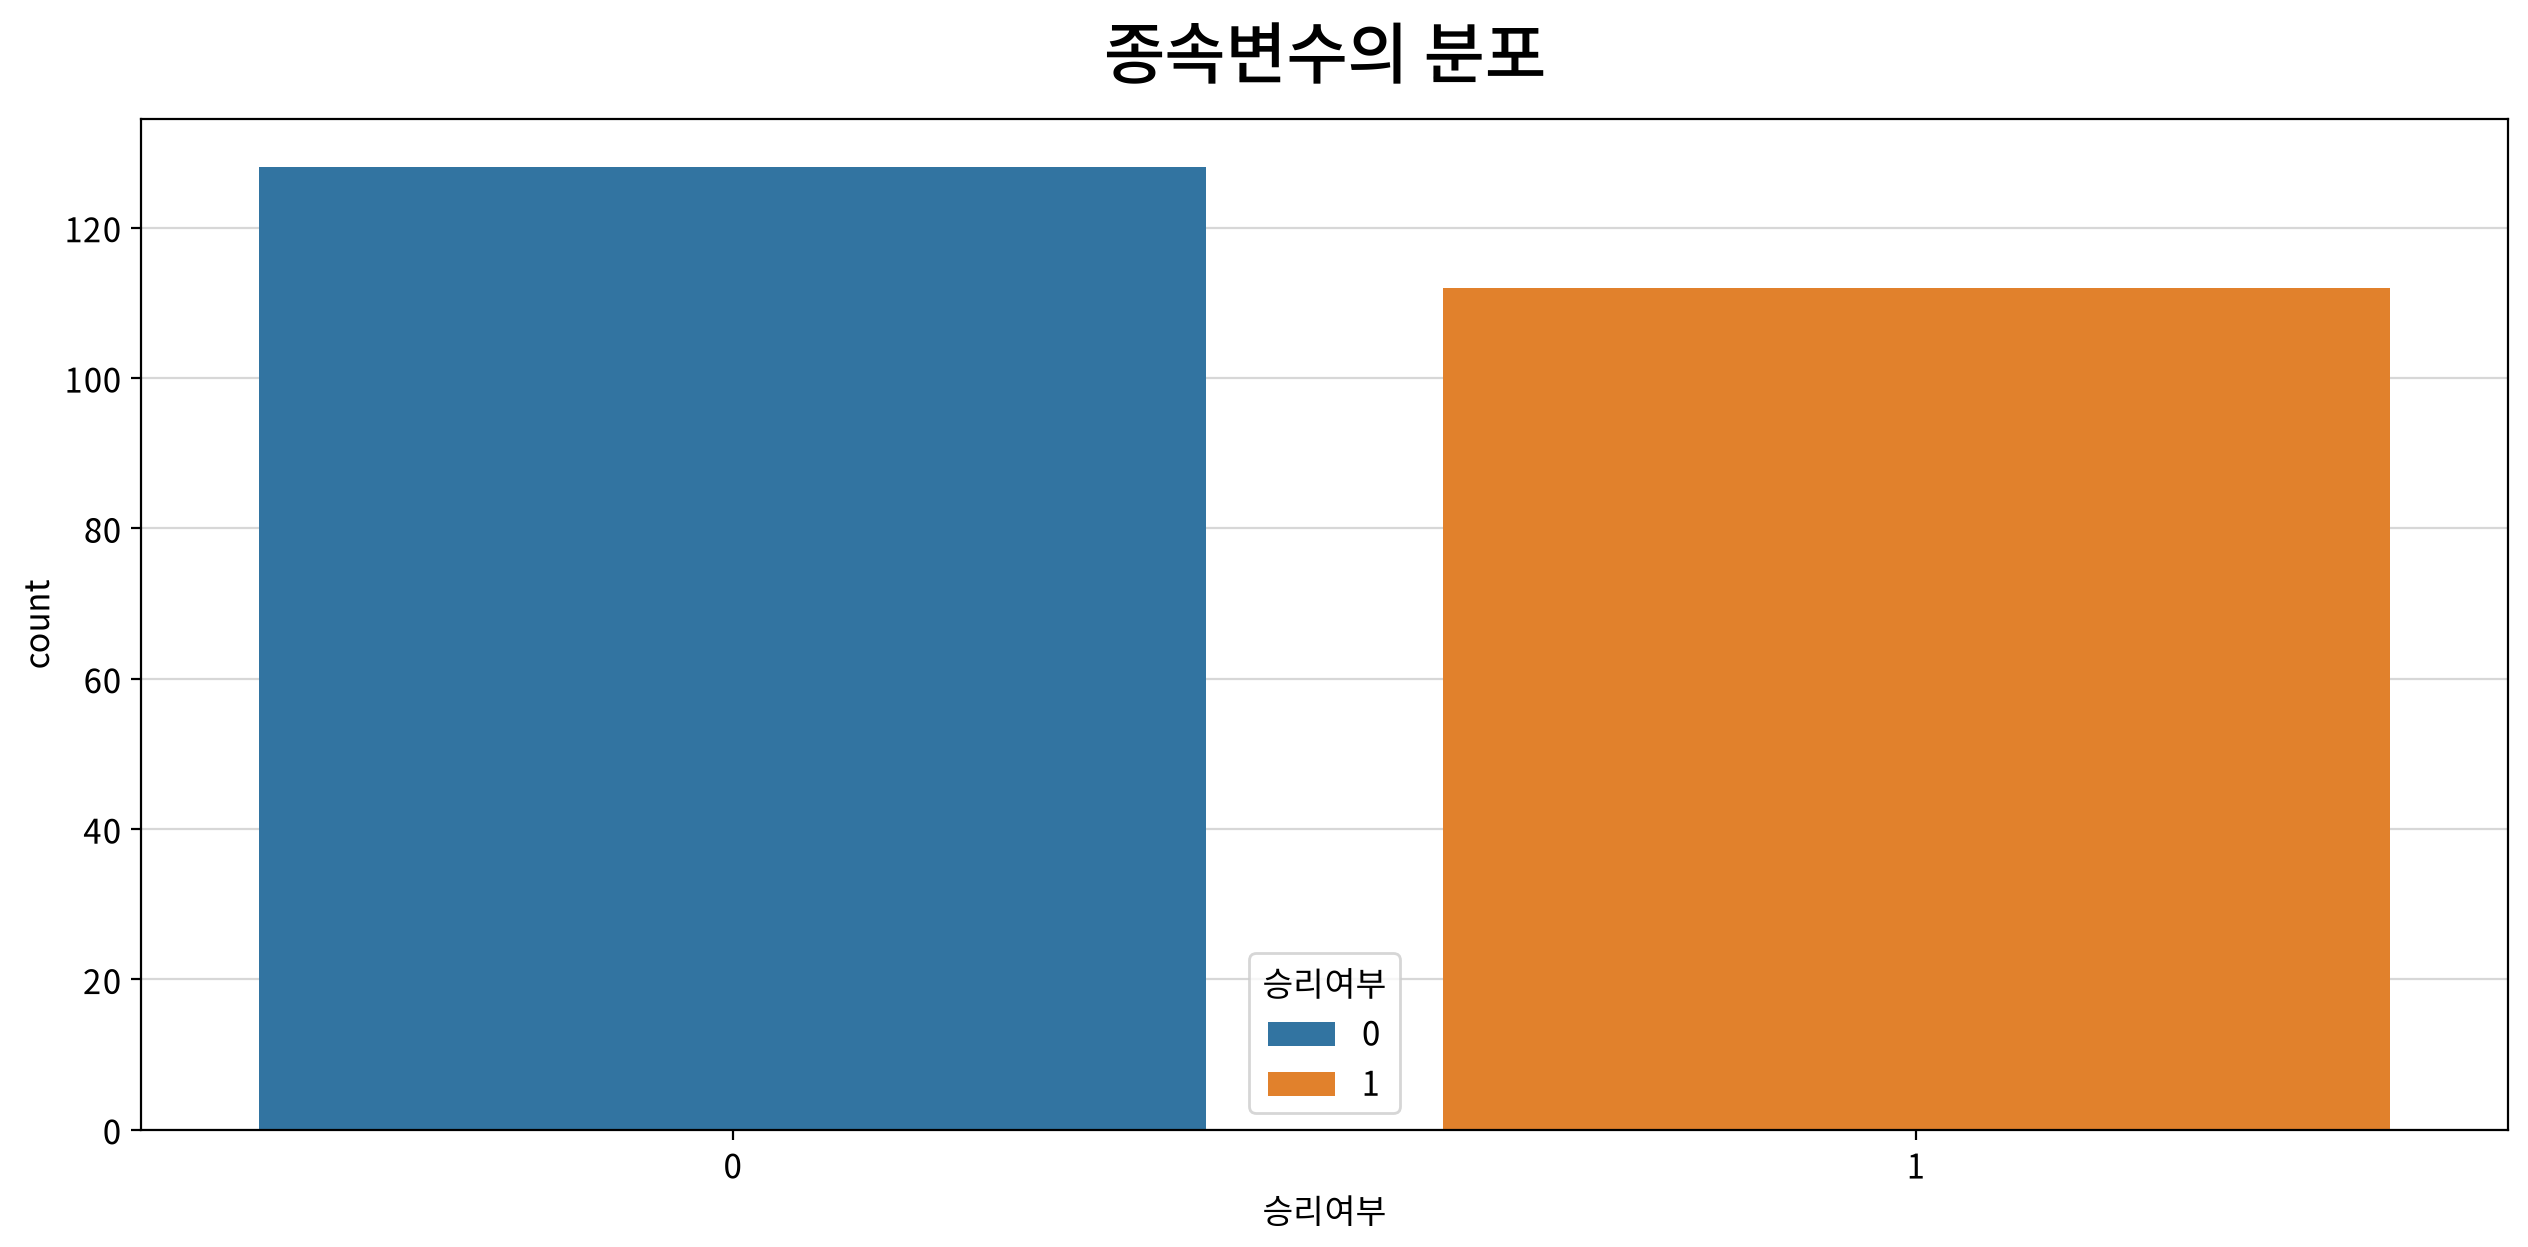

In [89]:
my_plot.countplot(origin, x='승리여부', hue='승리여부', title='종속변수의 분포')

In [90]:
# 승리여부에 따라서, 
# 승리
# 실패 
# 실점을 보기 

origin.groupby('승리여부')['실점'].mean()

승리여부
0   3.766
1   2.357
Name: 실점, dtype: float64

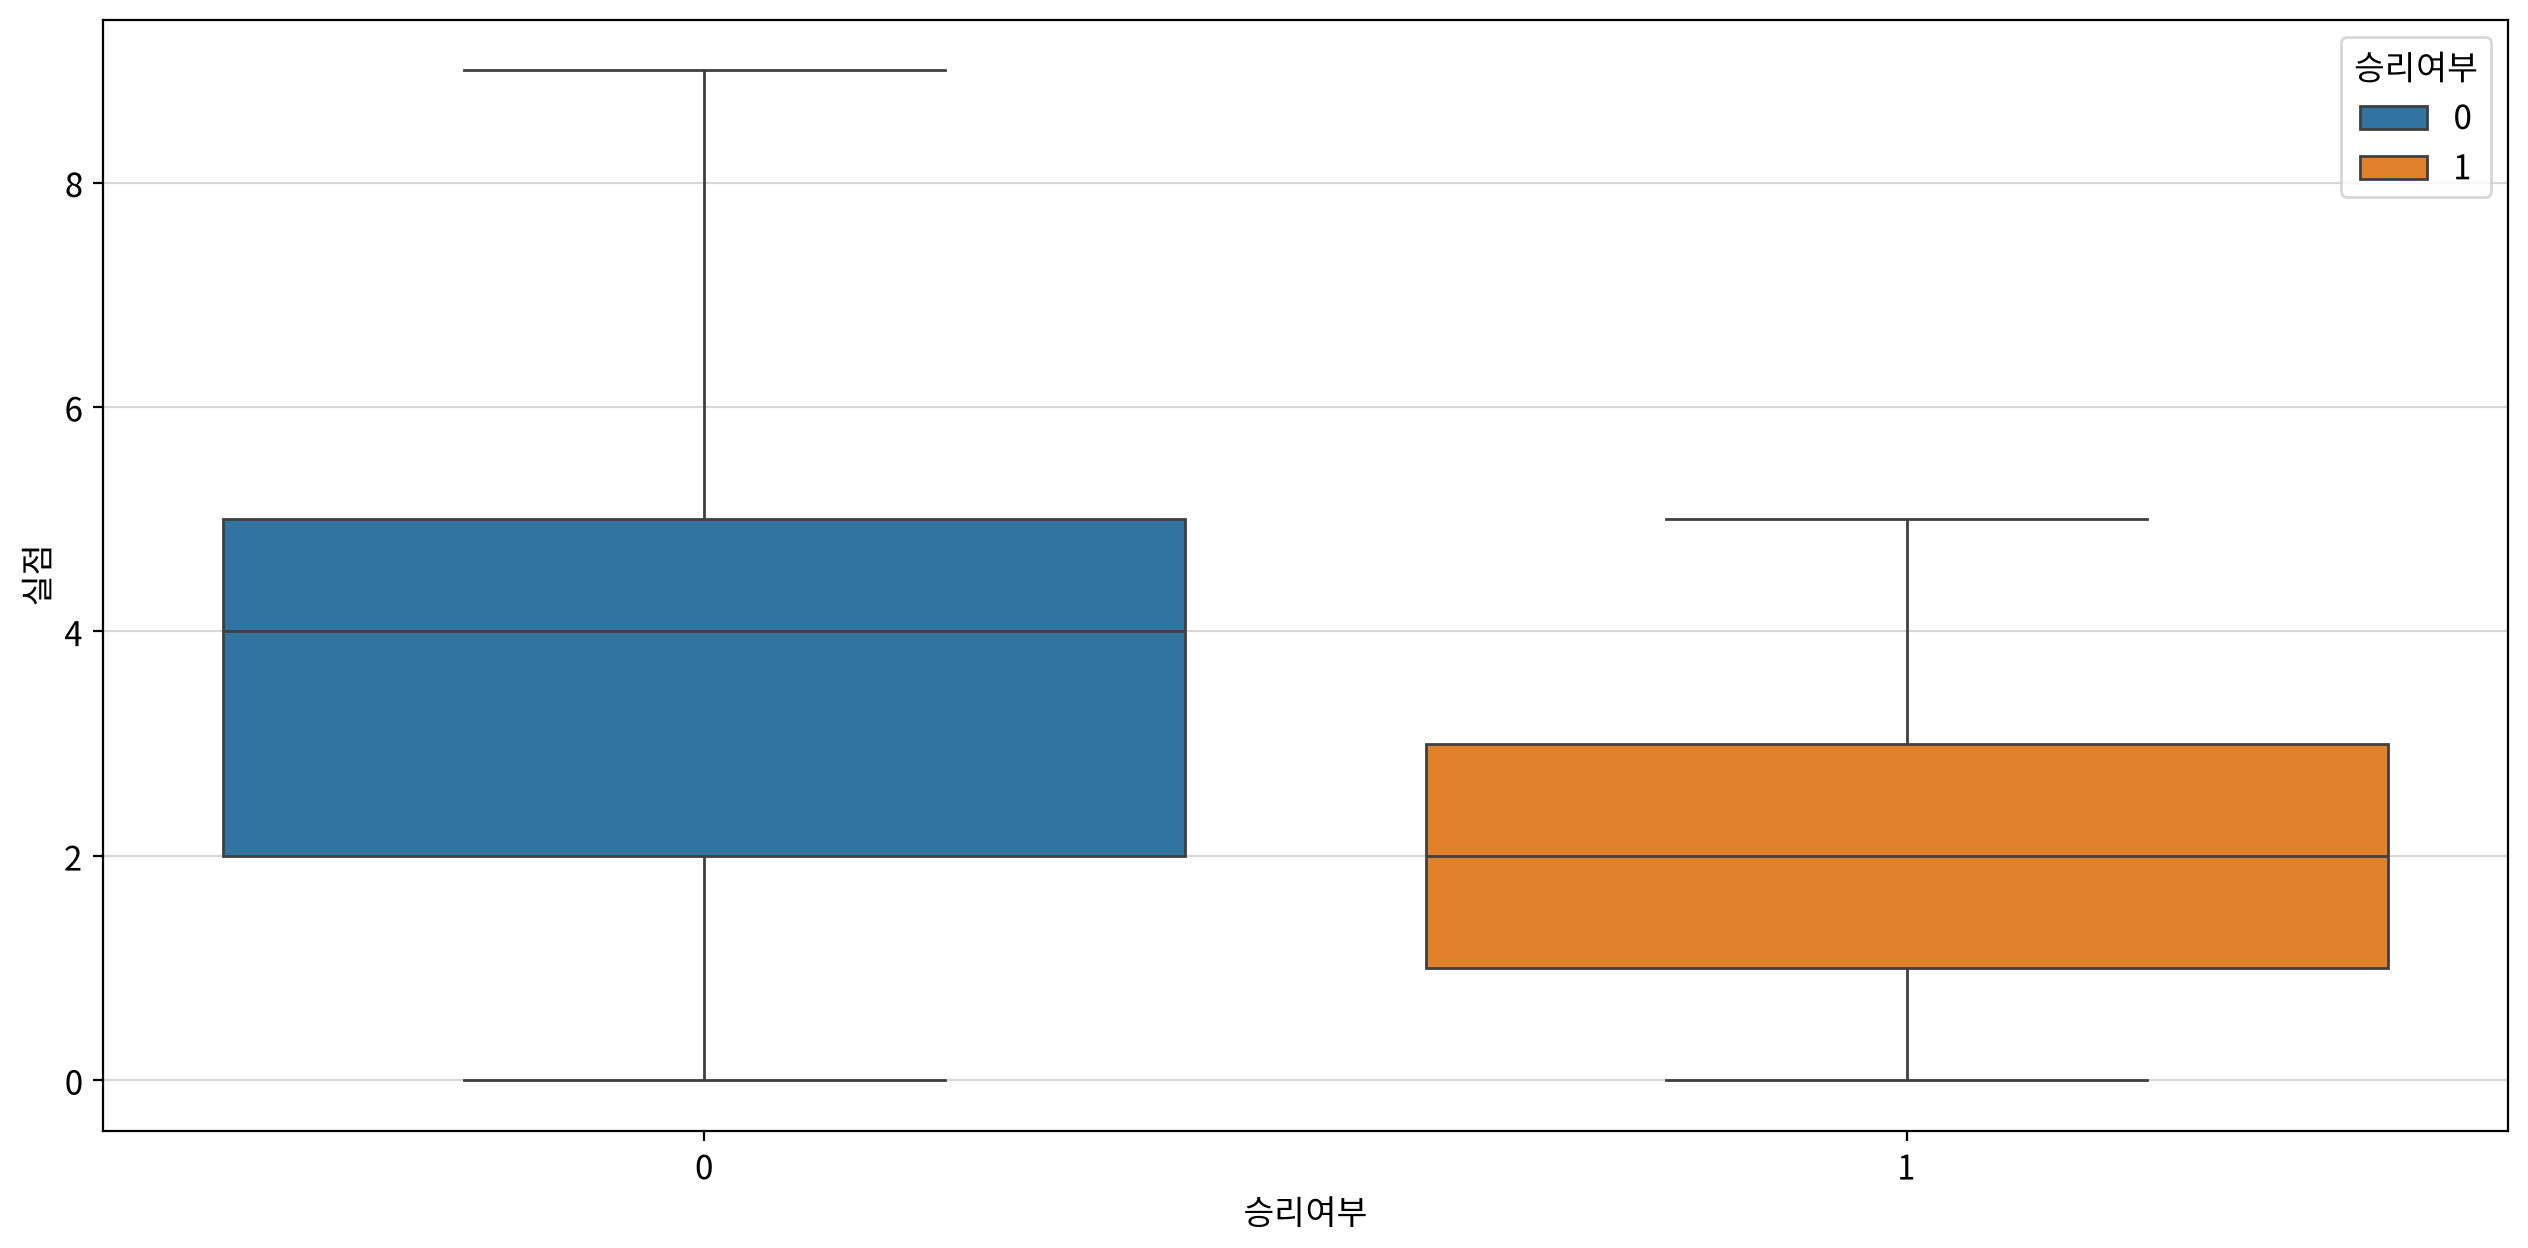

In [91]:
my_plot.boxplot(origin, x='승리여부', y='실점', hue='승리여부')

In [92]:
# 로지스틱 회귀 
fit = my_logit.fit_model(df, y='승리여부', summary=True)

                           Logit Regression Results                           
Dep. Variable:                   승리여부   No. Observations:                  240
Model:                          Logit   Df Residuals:                      238
Method:                           MLE   Df Model:                            1
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1305
Time:                        17:59:29   Log-Likelihood:                -144.19
converged:                       True   LL-Null:                       -165.82
Covariance Type:            nonrobust   LLR p-value:                 4.774e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5699      0.317      4.945      0.000       0.948       2.192
실점            -0.5624      0.096     -5.841      0.000      -0.751      -0.374


In [93]:
my_ols.auto_ols(df, '승리여부', report=True)

#### ▶︎ 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,승리여부,실점,-0.117,0.017,0.014,-0.406,-6.852,-8.531,0.000,0.000,1.000,1.000


**Note. n = 240. F(1, 238) = 46.95, p < 0.001, R² = 0.165, Adj.R² = 0.161, Durbin-Watson = 2.14**

승리여부를 종속변수로, 실점(을)를 독립변수로한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 238) = 46.95, p < 0.001, R² = 0.165.

즉, 실점는 승리여부의 약 16.48%를 설명하는 것으로 나타났다.

---

#### ▶︎ 회귀모형 가정 검정

...

루트MSE = 0.46 , 구간 규칙 판정: 정규성 위배


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,4.068,0.044,4.103,0.044,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.140,True,독립성 만족


In [94]:
pred = my_logit.predict(fit, df['실점'])
pred.head()

,proba,pred
0,0.336,0
1,0.733,1
2,0.471,0
3,0.471,0
4,0.609,1


In [95]:
new_df = df.copy()
new_df[['proba', 'pred']] = pred

new_df.head()

,실점,승리여부,proba,pred
0,4,0,0.336,0
1,1,1,0.733,1
2,3,0,0.471,0
3,3,1,0.471,0
4,2,0,0.609,1


In [96]:
# 분류 경계 확인 
# pred 값이 승리 -> 패배로 바뀌는 지점을 데이터에서 직접 관찰 또는 계산


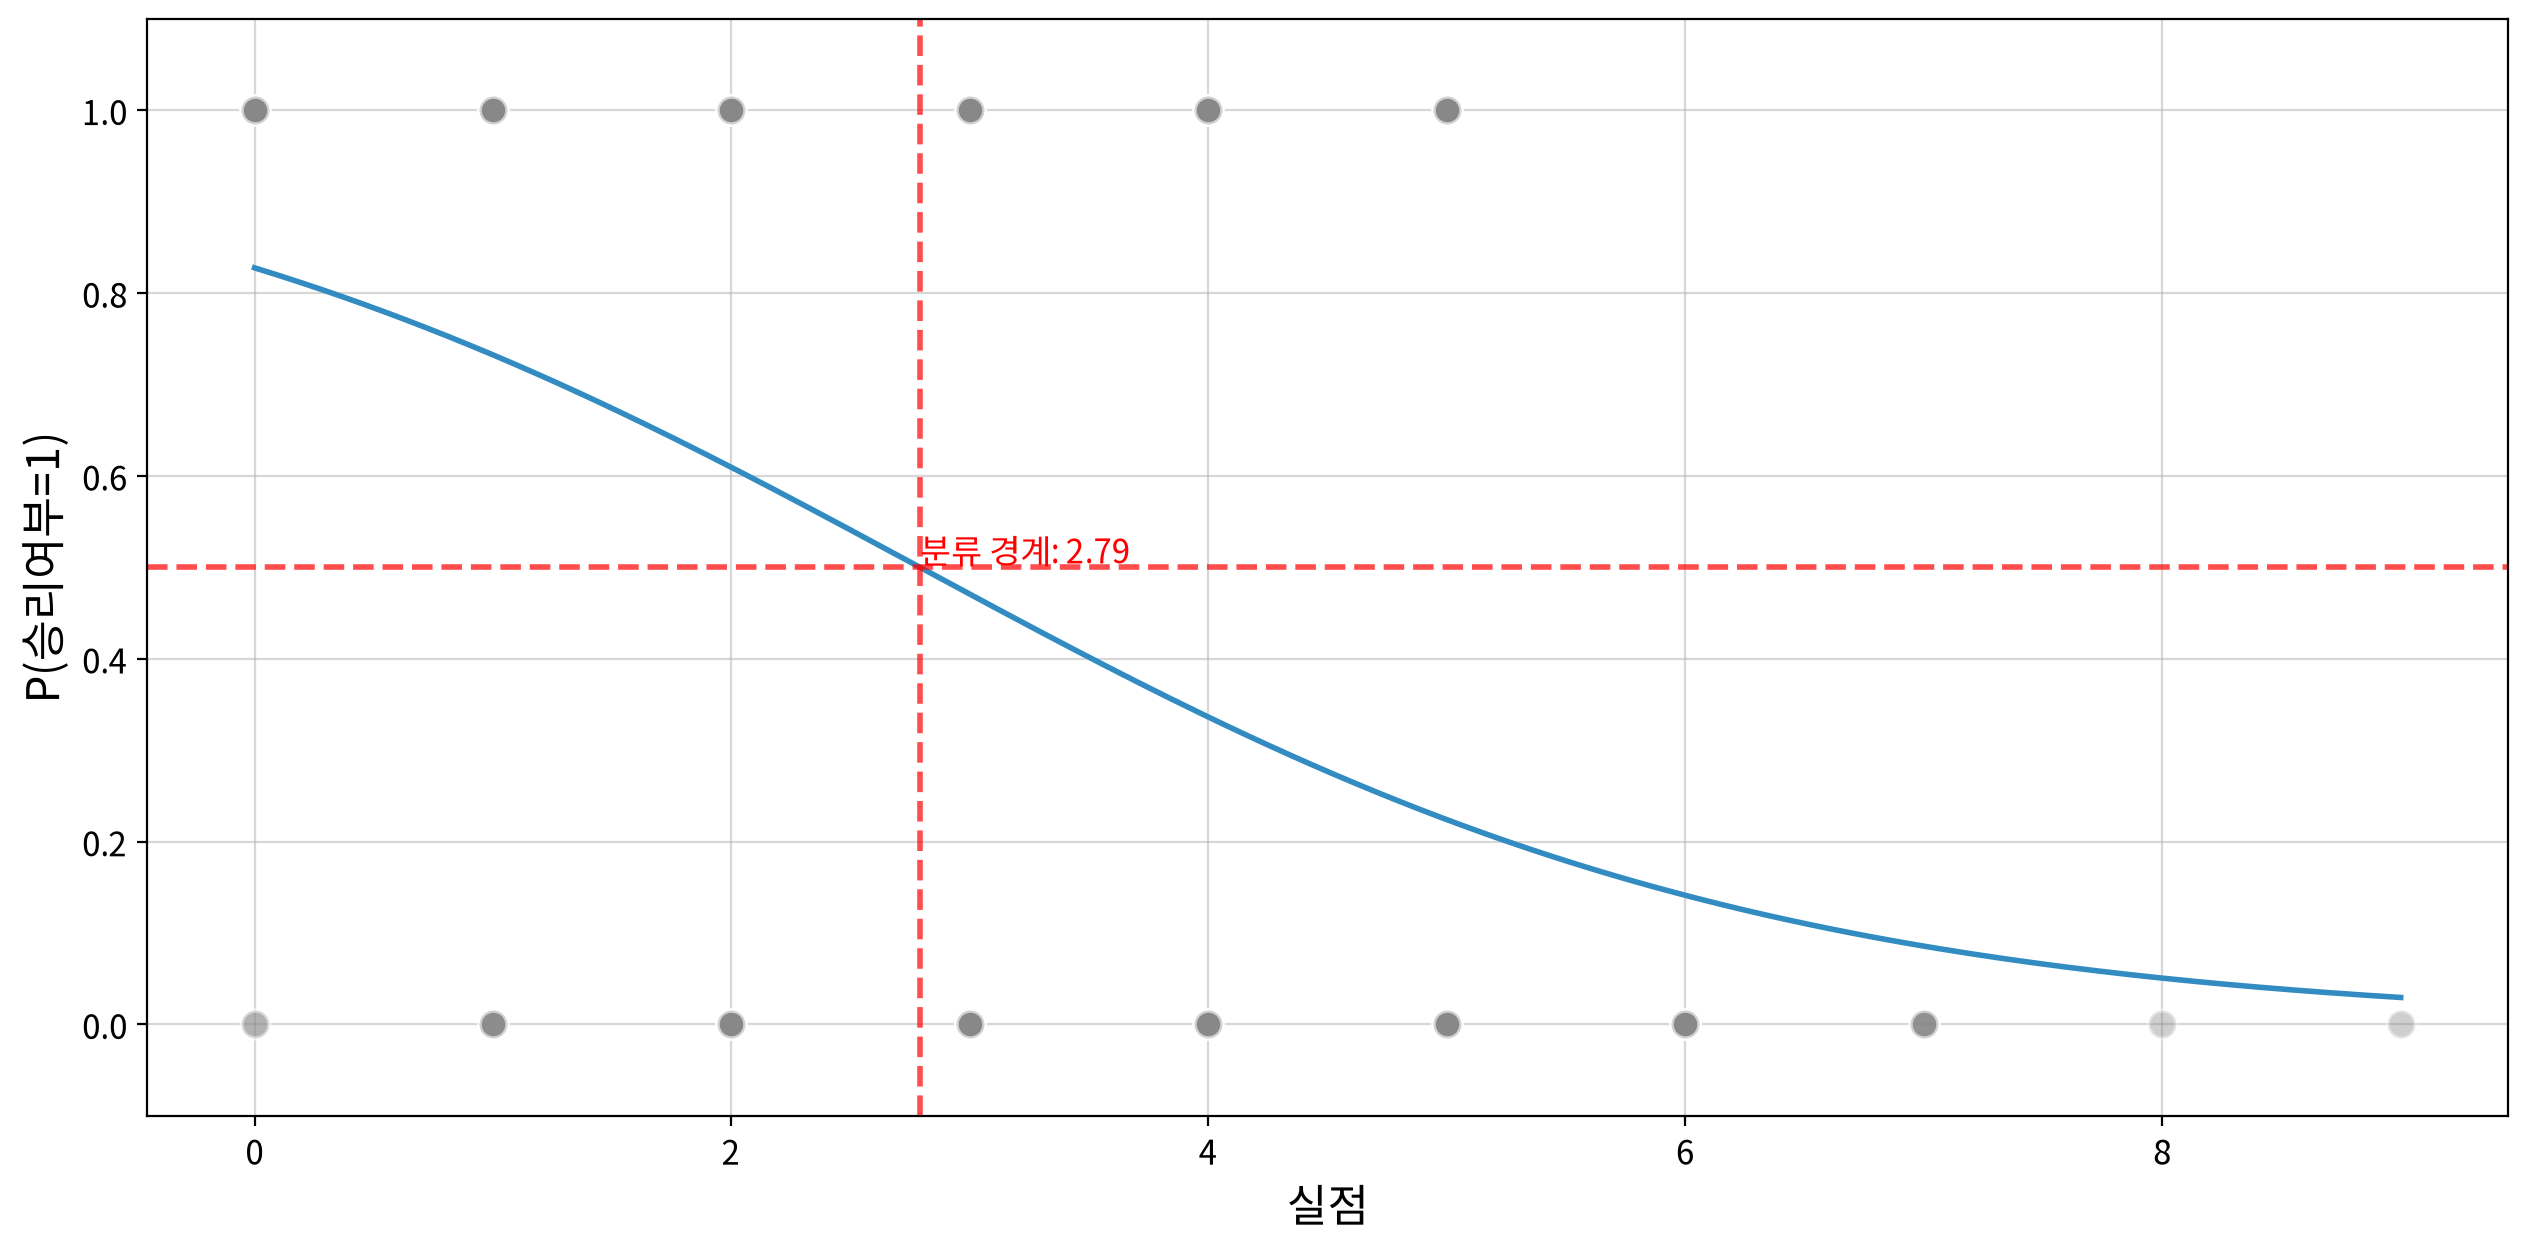

In [97]:
my_logit.plot_sigmoid(fit, new_df, x='실점')

In [98]:
## 10-2 연습문제 

In [99]:
# 데이터셋 불러오기 
# 불러온 데이터 셋 확인
# 결측치
# 중복값
# 0값

# 로지스틱 회귀를 해야 함
# 범주형 라벨링 
# 0 /1 

# 여기 문제에서, 
# 분석 대상 컬럼만 추출해야 함 

# 균형인지, 불균형인지
# 데이터 갯수 확인 



# 1의 평균할당 

# 오즈비 

In [111]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import Markdown, display

In [112]:
origin = load_data("pima_indians_diabetes") 
origin.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [113]:
my_qtcheck.check_missing_values(origin)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
SkinThickness,0,0.000
Insulin,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


In [114]:
my_qtcheck.set_type(origin)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.900,0.171,63,0
764,2,122,70,27,0,36.800,0.340,27,0
765,5,121,72,23,112,26.200,0.245,30,0
766,1,126,60,0,0,30.100,0.349,47,1


In [115]:
df = origin[['Glucose', 'Outcome']]
df = my_prep.labeling(df, columns=['Outcome'])
df.head()

Outcome (1종) : 0=0
Outcome (2종) : 0=0, 1=1


,Glucose,Outcome
0,148,1
1,85,0
2,183,1
3,89,0
4,137,1


In [116]:
origin['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

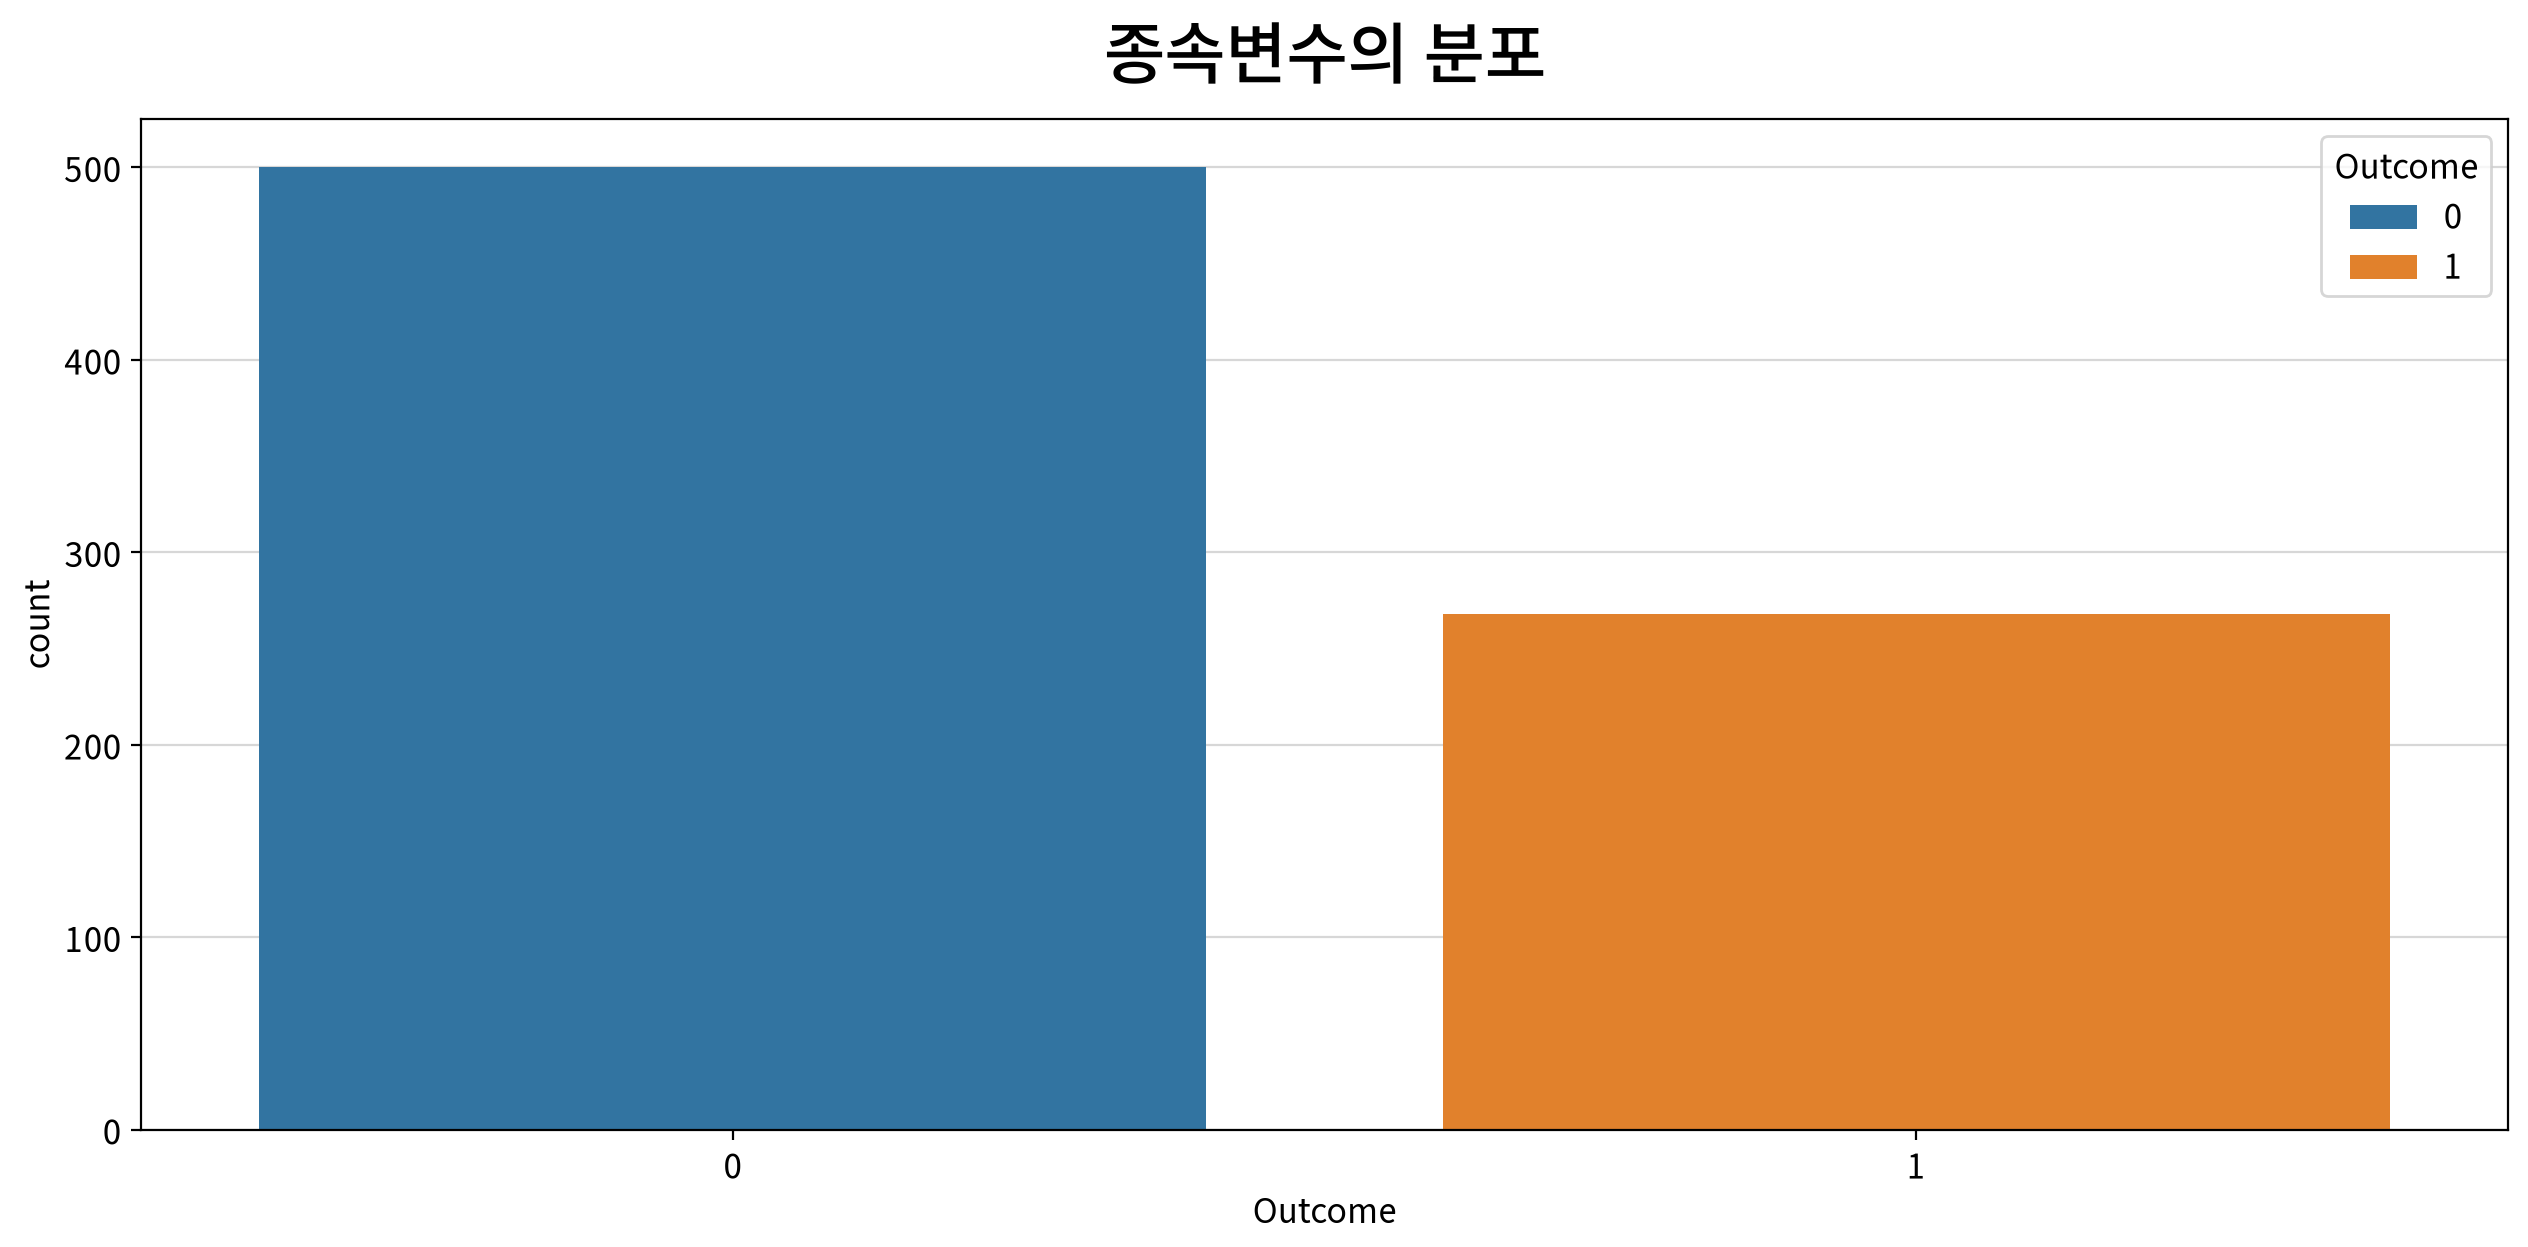

In [117]:
my_plot.countplot(origin, x='Outcome', hue='Outcome', title='종속변수의 분포')

In [118]:
# groupby 
# 0 /1 그룹으로 묶어서, 

df.groupby('Outcome')['Glucose'].mean()

Outcome
0   109.980
1   141.257
Name: Glucose, dtype: float64

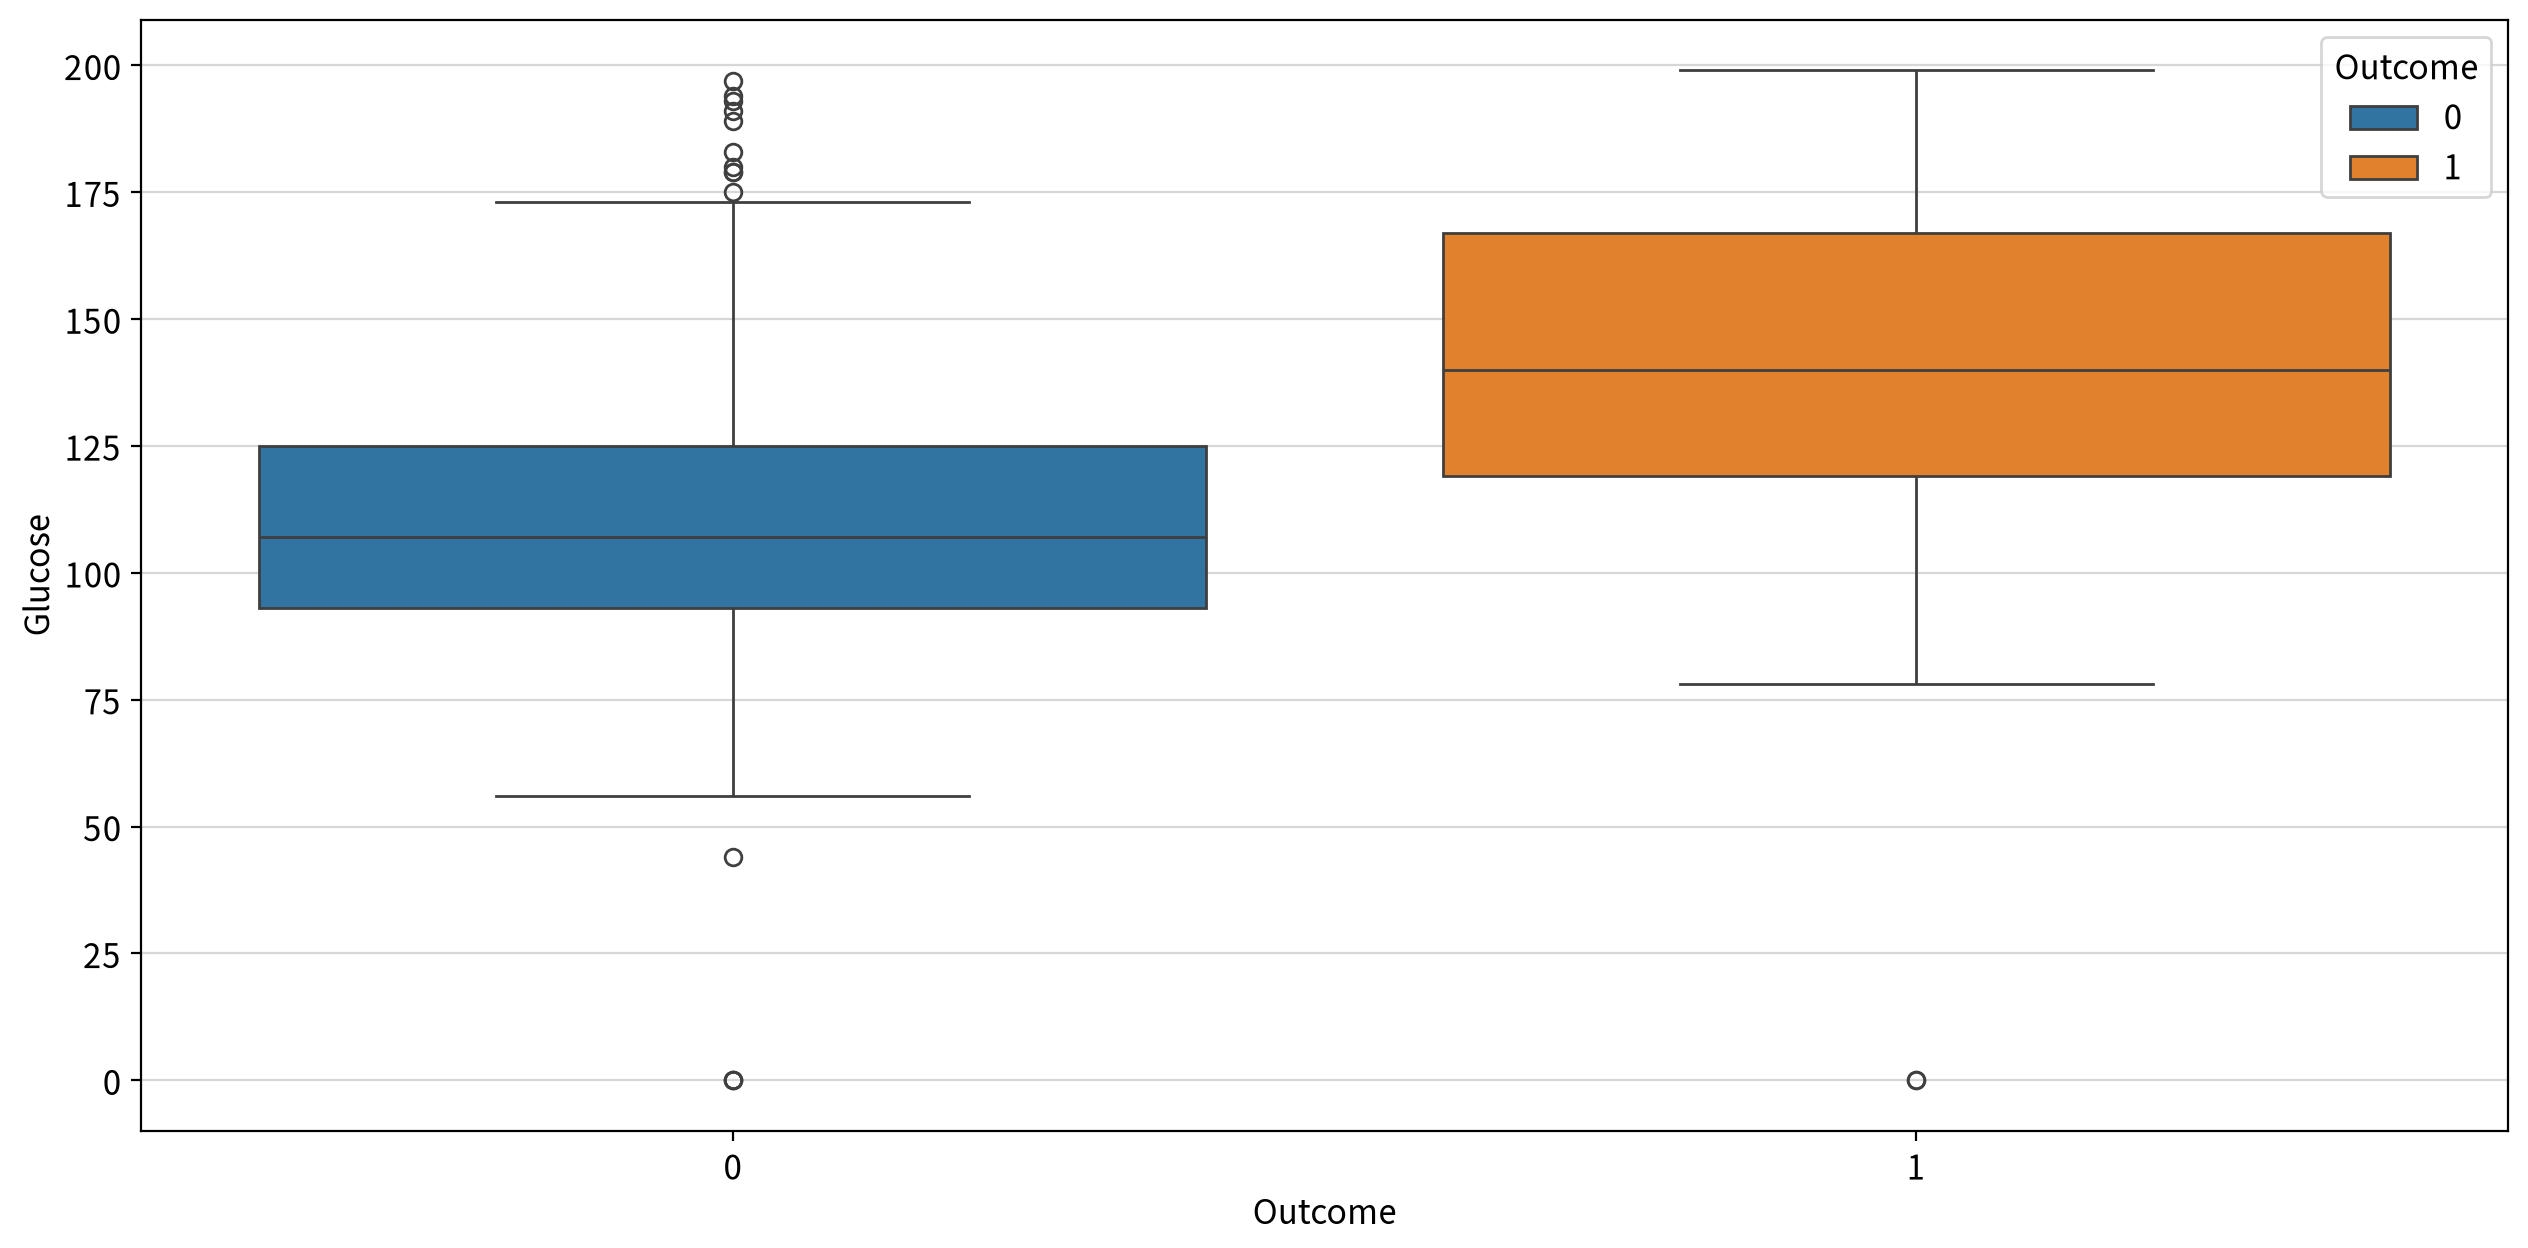

In [119]:
my_plot.boxplot(df, x='Outcome', y='Glucose', hue='Outcome')

In [120]:
fit1 = my_logit.fit_model(df, y='Outcome', summary=True)
fit1

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1860
Time:                        18:00:34   Log-Likelihood:                -404.36
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 4.418e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3501      0.421    -12.713      0.000      -6.175      -4.525
Glucose        0.0379      0.003     11.647      0.000       0.031       0.044


In [122]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n=768.LL = -404.36, LL-Null = -496.742, LLR x^2 (1) = 184.764, p < 0.001, Pseudo R^2 = 0.186**

Outcome를 종속변수로, Glucose(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x^2 (1)=184.764, p < 0.001, Pseudo R^2 = 0.186.

즉, 모형의 유사결정계수는 0.186로 양호한적합 수준을 보였다.

> Pseudo R^2는 선형회귀의 R^2처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다

In [127]:
display(my_logit.report_variables(fit1, df))

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,Glucose,0.038,1.211,0.003,11.647,0.000,1.039,1.032,1.045,1.000,1.000


In [129]:
display(Markdown(my_logit.report_variables_text(fit1, data=df)))

- **Glucose**의 회귀계수는 **B = 0.0379**, 오즈비는 **OR=1.0386**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 11.65**, **p < .001**)즉, **Glucose**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.9% 증가** 하는 것으로 해석된다.

> 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된)범주' 대비 값이다

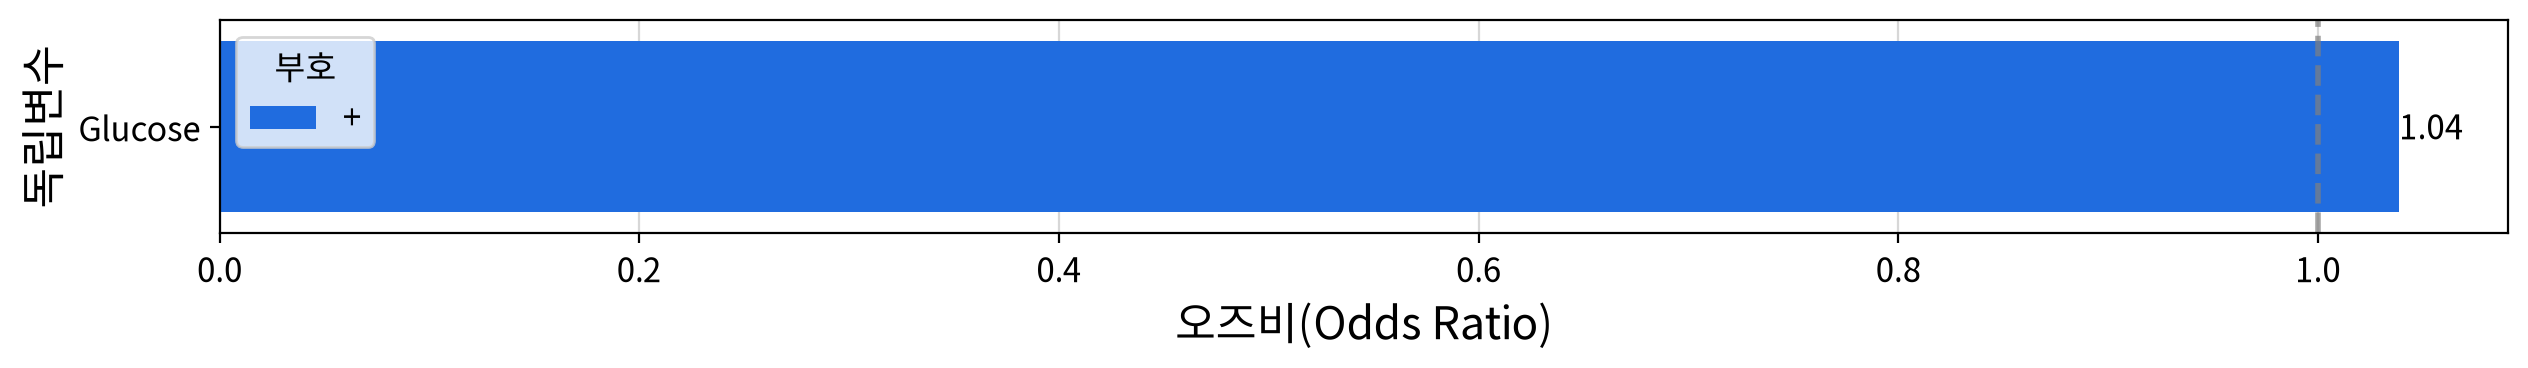

In [130]:
my_logit.plot_odds(fit1, df)